<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" style="width: 30%;">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Estabilidade de colunas

### Problema 2

Um viga encastrada numa extremidade e apoiada na outra é construída com um tubo de aço com área da secção transversal igual a 1000 mm $^2$. Sabendo que o comprimento da viga é 2,86 m determine a sua esbelteza e a sua carga crítica quando o quociente entre os diâmetros externo e interno é: a) 2.00 ; b) 1,50. Considere $E =$ 210 GPa.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au12/P2/MSII_Au12_P2.png"
style="width: 30%;"/>

### Resolução

A fórmula de Euler para instabilidade elástica de colunas submetidas a forças de compressão axial é dada por:

\begin{equation*}
P_{cr} = \frac{\pi^2 EI}{L_e^2}
\end{equation*}

O valor de $L_e$ depende das condições de apoio da coluna. Devido ao tipo de apoio de encastramento, é possível provar que o comprimento equivalente é dado por:

\begin{equation*}
L_e = 0,7 L
\end{equation*}

A tensão crítica na coluna vem:

\begin{equation*}
\sigma_{cr} = \frac{P_{cr}}{A} = \frac{\pi^2 EI}{A L_e^2}
\end{equation*}

Introduzindo o conceito de raio de giração, $r_x$, e coeficiente de esbelteza, $\lambda$:

\begin{equation*}
r = \sqrt{\frac{I}{A}} \quad\wedge\quad \lambda_e = \frac{L_e}{r}
\end{equation*}

a tensão crítica pode também ser expressa por,

\begin{equation*}
\sigma_{cr} = \frac{\pi^2 E}{\lambda^2}
\end{equation*}

**Raio de Giração**

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au12/P2/RaioGiracao.png"
style="width: 30%;"/>

Considere uma determinada área $A$ com um momento de inércia $I_x$ em relação ao eixo $x$. Se concentrarmos esta área numa região plana e estreita, paralela ao eixo $x$, e com o mesmo momento de inércia $I_x$, chama-se **raio de giração** à distância dessa região ao eixo $x$. Define-se raio de giração como sendo a raiz quadrada da relação entre o momento de inércia e a área da superfície. A unidade do raio de giração é o comprimento. O raio de giração é uma quantidade usada no estudo da instabilidade elaśtica de colunas.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sy
from sympy.solvers import solve
from typing import NamedTuple

# Dados
# unidades SI: m, Pa, N
class dados(NamedTuple):
    # dimensoes inicial e final da placa
    A : float 
    L : float
    # modulo elasticidade
    E : float
    # quociente entre os diâmetros externo e interno
    dedi_1 : float
    dedi_2 : float
    
var = dados(1000.e-6, 2.86, 210.e9, 2.0, 1.5)
print(f'dados = {var}')

Le = 0.7*var.L
print(f'{Le = } m')

dados = dados(A=0.001, L=2.86, E=210000000000.0, dedi_1=2.0, dedi_2=1.5)
Le = 2.002 m


A área da secção é dada por:

\begin{equation*}
A = \frac{\pi}{4}(d_e² - d_i²) =  \pi (r_e² - r_i²)
\end{equation*}

O segundo momento de área da secção é dado por:

\begin{equation*}
I = \frac{\pi}{64}(d_e⁴ - d_i⁴) = \frac{\pi}{4}(r_e⁴ - r_i⁴)
\end{equation*}


In [3]:
de, di = sy.symbols('de di')
def area(e,i): return np.pi/4*(e**2 - i**2)
def I(e,i): return np.pi/64*(e**4 - i**4)
def Pcri(y,I,l): return np.pi**2*y*I/l**2
def RaioGiracao(i, a): return np.sqrt(i/a) 
def CoefEsbelteza(comp, raioG): return comp/raioG 

def print_sol_de_di(de, di):
    print(f"de/di = {de/di:.2f}")
    print(f"de = {de:.4f} m")
    print(f"di = {di:.4f} m")
    print(f"t = re-ri = {(de/2 - di/2)*1e3:.2f} mm")

def print_raio_elbelteza(rai, esb):
    print(f'Raio de Giracao = {rai:.3e} m')
    print(f'Coef. de Elbelteza = {esb:.1f}')

def print_A_I_sec_and_Pcri_Scri(A_sec, I_sec, Pcri_i, Scri_i):
    print(f'A_sec = {A_sec:.3e} m^2')
    print(f'I_sec = {I_sec:.3e} m^4')
    print(f'Pcri_i = {Pcri_i*1e-3:.1f} kN')
    print(f'Scri_i = {Scri_i*1e-6:.1f} MPa')

def resolucao(dedein):
    eq1 = var.A - area(de, di)
    eq2 = de / di - dedein
    sol = solve({eq1, eq2}, {di,de})
    sol_positive = [s for s in sol if all(val.is_real and val > 0 for val in s.values())]
    sol_de_di = sol_positive[0]
    de_ = float(sol_de_di[de])
    di_ = float(sol_de_di[di])
    
    print_sol_de_di(de_, di_) 
    
    A_sec = area(de_, di_)
    I_sec = I(de_, di_)
  
    RG = RaioGiracao(I_sec, var.A)
    CE = CoefEsbelteza(Le,RG)
    print_raio_elbelteza(RG,CE)
      
    Pcri_i = Pcri(var.E ,I_sec, Le)
    Scri_i = Pcri_i / var.A
    print_A_I_sec_and_Pcri_Scri(A_sec, I_sec, Pcri_i, Scri_i)
    
    return de_, di_, A_sec, I_sec, RG, CE, Pcri_i, Scri_i


De notar que, secções tubulares com diferentes rácios $d_e/d_i$ produzem diferentes momento de inércia. Como as restantes variáveis no modelo de Euler para a instabilidade elástica ou encurvadura são constantes, a tensão crítica dependerá exclusivamente do momento de inércia, sendo maior para a secção com maior momento de inércia:

\begin{equation*}
\sigma_{cr} = \left(\frac{\pi^2 E}{A L_e^2}\right) I
\end{equation*}

O algoritmo de resolução segue a seguinte sequência:

\begin{equation*}
\left( A, \frac{d_e}{d_i} \right)
\quad\rightarrow\quad
d_i, d_2
\quad\rightarrow\quad
I
\quad\rightarrow\quad
r
\quad\rightarrow\quad
\lambda
\quad\rightarrow\quad
\sigma_{cr}
\end{equation*}

#### (a) Quociente entre os diâmetros externo e interno de 2.00

Desenvolvendo para o rácio:

\begin{equation*}
\frac{d_e}{d_i} = \frac{r_e}{r_i} = 2
\quad\wedge\quad
I_{d_e/d_i = 2}
\end{equation*}


In [4]:
de_1, di_1, A_1, I_1, rg_1, esb_1, Pcr_1, Scr_1 = resolucao(var.dedi_1)

de/di = 2.00
de = 0.0412 m
di = 0.0206 m
t = re-ri = 10.30 mm
Raio de Giracao = 1.152e-02 m
Coef. de Elbelteza = 173.8
A_sec = 1.000e-03 m^2
I_sec = 1.326e-07 m^4
Pcri_i = 68.6 kN
Scri_i = 68.6 MPa


#### (b) Quociente entre os diâmetros externo e interno de 1,50

\begin{equation*}
\frac{d_e}{d_i} = \frac{r_e}{r_i} = 1,5
\quad\wedge\quad
I_{d_e/d_i = 1,5}
\end{equation*}

In [5]:
de_2, di_2, A_2, I_2, rg_2, esb_2, Pcr_2, Scr_2 = resolucao(var.dedi_2)

de/di = 1.50
de = 0.0479 m
di = 0.0319 m
t = re-ri = 7.98 mm
Raio de Giracao = 1.438e-02 m
Coef. de Elbelteza = 139.2
A_sec = 1.000e-03 m^2
I_sec = 2.069e-07 m^4
Pcri_i = 107.0 kN
Scri_i = 107.0 MPa


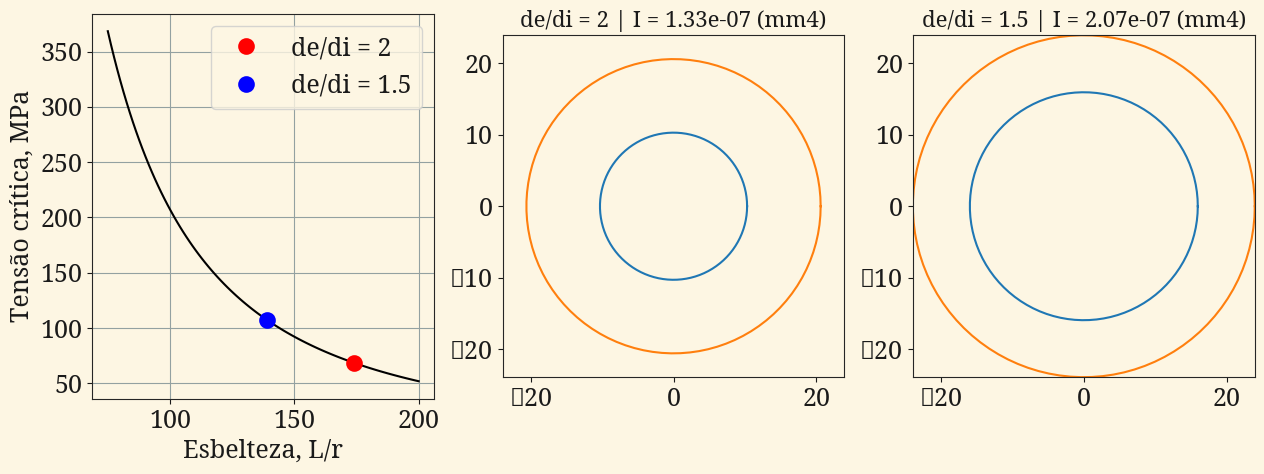

In [10]:
CE_var = np.linspace(75, 200, 100)

def Scri_var(y, esb): return np.pi**2*y / esb**2

scri_var_E = Scri_var(var.E, CE_var)

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Noto Serif' # 'Roboto Slab'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

def plot_tube_cross_section(ax, di, de):
    # Generate theta values
    theta = np.linspace(0, 2 * np.pi, 100)

    # Calculate x and y coordinates for the inner circle
    xi = di/2 * np.cos(theta)
    yi = di/2 * np.sin(theta)

    # Calculate x and y coordinates for the outer circle
    xo = de/2 * np.cos(theta)
    yo = de/2 * np.sin(theta)

    # Plot the circles on the specified axes
    ax.plot(xi, yi, label='Inner Circle')
    ax.plot(xo, yo, label='Outer Circle')
    
# plt.figure(figsize=(7,5))
# plt.plot(CE_var, scri_var_E*1e-6, 'k-')
# plt.plot(esb_1, Scr_1*1e-6, 'o', markersize=10, markerfacecolor='r', markeredgecolor='r', markeredgewidth=2, label='de/di = 2' )
# plt.plot(esb_2, Scr_2*1e-6, 'o', markersize=10, markerfacecolor='b', markeredgecolor='b', markeredgewidth=2, label='de/di = 1.5')
# plot_tube_cross_section(di_1, de_1)
# plt.xlabel('Esbelteza, L/r')
# plt.ylabel('Tensão crítica, MPa')
# #plt.legend()
# plt.grid(True)
# plt.show()

# Create a figure with subplots
fig, ax = plt.subplots(figsize=(15, 5), ncols=3)

# Plot on the first subplot
ax[0].plot(CE_var, scri_var_E*1e-6, 'k-')
ax[0].plot(esb_1, Scr_1*1e-6, 'o', markersize=10, markerfacecolor='r', markeredgecolor='r', markeredgewidth=2, label='de/di = 2')
ax[0].plot(esb_2, Scr_2*1e-6, 'o', markersize=10, markerfacecolor='b', markeredgecolor='b', markeredgewidth=2, label='de/di = 1.5')
ax[0].set_xlabel('Esbelteza, L/r')
ax[0].set_ylabel('Tensão crítica, MPa')
ax[0].legend()
ax[0].grid(True)

# Plot the tube cross-section on the second subplot
plot_tube_cross_section(ax[1], di_1*1e3, de_1*1e3)
ax[1].set_aspect('equal', adjustable='box')  # Set aspect ratio to keep circles circular
ax[1].set_title(f'de/di = 2 | I = {I_1:.2e} (mm4)', fontsize = 16) 
ax[1].set_xlim(-de_2*1e3/2, de_2*1e3/2)
ax[1].set_ylim(-de_2*1e3/2, de_2*1e3/2)

# Plot the tube cross-section on the third subplot
plot_tube_cross_section(ax[2], di_2*1e3, de_2*1e3)
ax[2].set_aspect('equal', adjustable='box')  # Set aspect ratio to keep circles circular
ax[2].set_title(f'de/di = 1.5 | I = {I_2:.2e} (mm4)', fontsize = 16) 
ax[2].set_xlim(-de_2*1e3/2, de_2*1e3/2)
ax[2].set_ylim(-de_2*1e3/2, de_2*1e3/2)

# Show the plot
plt.show()

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au12/P2/SigmaCritico.png"
style="width: 50%;"/>

#### Apêndice 

Considere-se uma viga em encastrada-articulada como ilustrada neste problema.

Pela deflexão da coluna devida à força aplicada $P$, ocorrera uma reação vertical $.Q$ De igual foma, surgirá um momento
e forças de reação horizontais e verticais no encastramento.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au12/P2/Apendice01.png"
style="width: 30%;"/>


A equação diferencial da linha elástica toma a seguinte forma para este problema:

\begin{equation*}
EI \frac{d^2y}{dx^2} = M(x), \quad\textrm{com}\quad M(x) = -Py + Q(L-x)
\end{equation*}

ou seja,

\begin{equation*}
EI \frac{d^2y}{dx^2} + Py = Q(L-x)
\end{equation*}


A equação diferencial da elástica toma a forma de uma equação diferencial linear de 2ª ordem, não homogénea, de coeficientes constantes.

A solução para este tipo de equações diferenciais é dada por:

\begin{equation*}
y(x) = y_h(x) + y_p(x)
\end{equation*}

onde a solução homogénea é dada por:

\begin{equation*}
y_h(x) = c_1 \sin(wx) + c_2 \cos(wx) 
\quad\wedge\quad w= \sqrt{\frac{P}{EI}}
\end{equation*}

e a solução particular vem:

\begin{equation*}
y_p(x) = \frac{Q}{P}(L-x)
\end{equation*}

resultando as seguintes equações para a deflexão:

\begin{equation*}
y(x) = c_1 \sin(wx) + c_2 \cos(wx) + \frac{Q}{P}(L-x)
\end{equation*}

e para a rotação,

\begin{equation*}
\theta = y'(x) = c_1 \cos(wx) - c_2 \sin(wx) - \frac{Q}{P}
\end{equation*}

As constantes nesta equação geral são determinadas pelas condições de fronteira do problema:

\begin{equation*}
    \begin{cases}
        y = 0 & \quad\text{ se } \quad x = 0 \\
        y = 0 & \quad\text{ se } \quad x = L \\
        \frac{dy}{dx} = 0 & \quad\text{ se } \quad x = 0 
    \end{cases}
\end{equation*}

desenvolvendo,

\begin{equation*}
    \begin{cases}
        0~&~= c_2 + \frac{Q}{P}L \\
        0~&~= c_1 \sin(wL) + c_2 \cos(wL) \\
        0~&~ = c_1 w - \frac{Q}{P} 
    \end{cases}
\end{equation*}


\begin{equation*}
    \begin{cases}
        c_2~&~= -\frac{Q}{P}L \\
        \tan(wL)~&~= - \frac{c_2}{c_1} = - wL \\
        c_1~&~= \frac{Q}{wP} 
    \end{cases}
\end{equation*}

A solução para $\tan(wL) = - wL$ resulta em:

\begin{equation*}
wL = 4,493
\quad\therefore\quad
w = 1.4303\frac{\pi}{L}
\end{equation*}

In [7]:
from scipy.optimize import newton

L = 1
w_initial_guess = 4.2
# Our function is tan(wL) + wL
def func(w):
    return np.tan(w*L) - w*L

# And its derivative is L(sec(wL)^2 + 1)
def func_deriv(w):
    return L*(np.power(1/np.cos(w*L),2) + L)

root = newton(func, w_initial_guess, fprime=func_deriv)

if 2 <= root <= 4.95:
    print(f'The solution in the interval [2, 4.95] is w = {root:.5f}.')
else: 
    print('No solution found within the interval [2, 4.95].')
    
w_ = root/np.pi
print(f'w = {w_:.5f} \u03C0/L')

The solution in the interval [2, 4.95] is w = 4.49341.
w = 1.43030 π/L


/home/slimbook/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


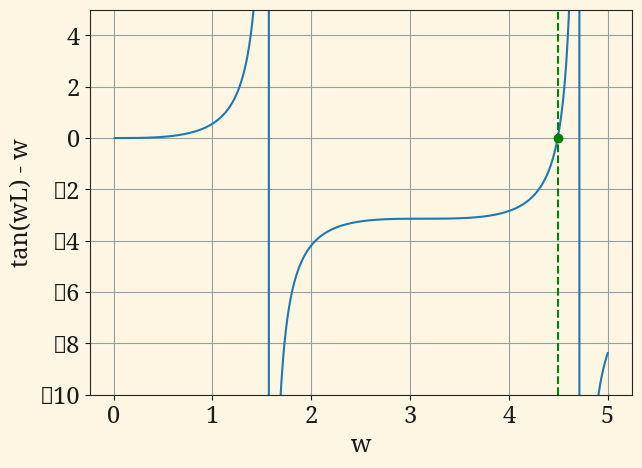

In [8]:
# Define w and L
L = 1
w = np.linspace(0.01, 5, 1000)

# Define the functions
y1 = w
y2 = np.tan(w * L) - y1

# Set global font size
plt.rcParams.update({'font.size': 17})

# Create the plot
plt.figure(figsize=(7,5))
plt.plot(y1, y2, label='tan(wL) - w')
plt.ylim(-10, 5)
plt.xlabel('w')
plt.ylabel('tan(wL) - w')
#plt.legend()
plt.grid(True)

# Display the intersection point
y2_rounded = np.round(y2, 2)

# Create a mask for the interval [2, 4.95]
mask = (y1 >= 2) & (y1 <= 4.97)
y1_masked = y1[mask]
y2_rounded_masked = y2_rounded[mask]

# Find intersection within this interval
idx_masked = np.argwhere(np.isclose(y2_rounded_masked, 0, atol=1e-2)).flatten()
plt.plot(y1_masked[idx_masked], y2_rounded_masked[idx_masked], 'ro')

# Plot the point w = 4.49341
plt.axvline(x=root, color='green', linestyle='--', label='w = 4.49341')
plt.plot(root, 0, 'go')  # Marker for the point


plt.show()

# Print intersection points
for intersect in y1_masked[idx_masked]:
    print(f'The intersection occurs at w = {intersect}')


Desta forma,

\begin{equation*}
w = 1.4303\frac{\pi}{L} = \sqrt{\frac{P_{cr}}{EI}}
\end{equation*}

Resultando finalmente,

\begin{equation*}
P_{cr} = \frac{\pi^2 EI}{(0,7L)^2}
\quad\text{com}\quad
L_e = 0,7L
\end{equation*}


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>